In [2]:
# =============================================================================
# SYSTEMATIC ERROR REDUCTION ANALYSIS
# One-vs-Rest Brain Region Classification
# =============================================================================

try:
    import numpy as np
    import pandas as pd
    import json
    from pathlib import Path
    import warnings
    import re

    # Visualization
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px

    # Machine Learning
    from sklearn.metrics import confusion_matrix

    # Configuration
    warnings.filterwarnings('ignore')
    pd.set_option('display.max_columns', None)
    pd.set_option('display.precision', 2)

    # Color Palette for Visualizations
    COLORS = {
        'baseline': '#e74c3c',      # Red
        'step1': '#f39c12',          # Orange  
        'step2': '#3498db',          # Blue
        'step3': '#2ecc71',          # Green
        'same_h_same_n': '#1A5276',
        'same_h_diff_n': '#1D8348',
        'diff_h_same_n': '#7D3C98',
        'diff_h_diff_n': '#2E4053'
    }
    print("Imports successful.")
except Exception as e:
    print(f"Import Error: {e}")

Imports successful.


In [3]:
# =============================================================================
# PATH VERIFICATION
# =============================================================================


BASE_PATH = Path('/home/sjoon/projects/brain_connectivity_classifier/data')
RESULTS_DIR = BASE_PATH / 'results'

# Template for repetitive paths
def res_p(sub, task): return RESULTS_DIR / sub / task
f_sub = 'full_connectivity_analysis'
l_sub, r_sub = 'hemisphere_analysis/left_hemisphere', 'hemisphere_analysis/right_hemisphere'
ovr, t_ovr = 'one_vs_rest', 'task_testing_one_vs_rest'

PATHS = {
    'full_cv': res_p(f_sub, ovr) / 'cv_summary.json',
    'full_task': res_p(f_sub, t_ovr) / 'task_testing_summary.json',
    'full_pred': res_p(f_sub, t_ovr) / 'task_predictions.npy',
    'full_true': res_p(f_sub, t_ovr) / 'task_true_labels.npy',
    
    'left_cv': res_p(l_sub, ovr) / 'cv_summary.json',
    'left_task': res_p(l_sub, t_ovr) / 'task_testing_summary.json',
    'left_pred': res_p(l_sub, t_ovr) / 'task_predictions.npy',
    'left_true': res_p(l_sub, t_ovr) / 'task_true_labels.npy',
    
    'right_cv': res_p(r_sub, ovr) / 'cv_summary.json',
    'right_task': res_p(r_sub, t_ovr) / 'task_testing_summary.json',
    'right_pred': res_p(r_sub, t_ovr) / 'task_predictions.npy',
    'right_true': res_p(r_sub, t_ovr) / 'task_true_labels.npy',
    
    'full_regions': BASE_PATH / 'FULL_region_info.csv',
    'lh_regions': BASE_PATH / 'LH_region_info.csv',
    'rh_regions': BASE_PATH / 'RH_region_info.csv',
    'coordinates': BASE_PATH / 'network_files' / 'Schaefer2018_200Parcels_Tian_32Parcels.csv'
}

# Condensed Verification
print("Path Verification:")
missing_paths = [n for n, p in PATHS.items() if not (print(f"  {'✓' if p.exists() else '✗'} {n}{'' if p.exists() else ' - MISSING'}") or p.exists())]

if missing_paths: print(f"\n⚠ Warning: {len(missing_paths)} path(s) missing")
else: print("\n✓ All paths verified successfully")

Path Verification:
  ✓ full_cv
  ✓ full_task
  ✓ full_pred
  ✓ full_true
  ✓ left_cv
  ✓ left_task
  ✓ left_pred
  ✓ left_true
  ✓ right_cv
  ✓ right_task
  ✓ right_pred
  ✓ right_true
  ✓ full_regions
  ✓ lh_regions
  ✓ rh_regions
  ✓ coordinates

✓ All paths verified successfully


In [4]:
# =============================================================================
# DATA LOADING
# =============================================================================
print("Loading data...\n")

# 1. Load region metadata
full_region_info = pd.read_csv(PATHS['full_regions'])
lh_region_info = pd.read_csv(PATHS['lh_regions'])
rh_region_info = pd.read_csv(PATHS['rh_regions'])
coords_df = pd.read_csv(PATHS['coordinates'])

print(f"✓ Metadata loaded: Full ({len(full_region_info)}), Left ({len(lh_region_info)}), Right ({len(rh_region_info)})")

# 2. Load performance summaries
def load_summary(path):
    with open(path, 'r') as f: return json.load(f)

s_keys = ['full_cv', 'full_task', 'left_cv', 'left_task', 'right_cv', 'right_task']
full_cv, full_task, left_cv, left_task, right_cv, right_task = [load_summary(PATHS[k]) for k in s_keys]

# 3. Load predictions and labels
p_keys = [('full_pred', 'full_true'), ('left_pred', 'left_true'), ('right_pred', 'right_true')]
preds_data = [ (np.load(PATHS[p], allow_pickle=True), np.load(PATHS[t], allow_pickle=True)) for p, t in p_keys]

(full_preds, full_true), (left_preds, left_true), (right_preds, right_true) = preds_data



print(f"\n✓ Summaries and Predictions loaded:")
print(f"  Full: {len(full_preds):,} | Left: {len(left_preds):,} | Right: {len(right_preds):,}")
print(f"\n DATA LOADING COMPLETE")

Loading data...

✓ Metadata loaded: Full (232), Left (116), Right (116)

✓ Summaries and Predictions loaded:
  Full: 46,400 | Left: 23,200 | Right: 23,200

 DATA LOADING COMPLETE


In [5]:
# =============================================================================
# BASELINE MODEL PERFORMANCE (Full Connectivity - 232 Regions)
# =============================================================================

def calculate_metrics(cv_data, task_data, predictions, true_labels):
    # Extract fold metrics and calculate means
    v_accs = [f['val_accuracy'] for f in cv_data['fold_metrics']]
    t_accs = [f['train_accuracy'] for f in cv_data['fold_metrics']]
    
    cv_t, cv_v = np.mean(t_accs) * 100, np.mean(v_accs) * 100
    task_a = task_data['task_test_accuracy'] * 100
    t_errs = np.sum(predictions != true_labels)
    t_samp = len(predictions)
    
    return {
        'cv_train_acc': cv_t, 'cv_val_acc': cv_v, 'generalization_gap': cv_t - cv_v,
        'task_acc': task_a, 'accuracy_drop': cv_v - task_a,
        'total_samples': t_samp, 'total_errors': t_errs, 'error_rate': (t_errs / t_samp) * 100
    }

# Calculate and Print
m = calculate_metrics(full_cv, full_task, full_preds, full_true)
baseline_metrics = m # Keep original name for downstream use

print(f"{'='*80}\nBASELINE MODEL PERFORMANCE (Full Connectivity)\n{'='*80}")
print(f"\nCV Performance:\n  Train: {m['cv_train_acc']:.2f}% | Val: {m['cv_val_acc']:.2f}% | Gap: {m['generalization_gap']:.2f}%")
print(f"\nTask Performance:\n  Test:  {m['task_acc']:.2f}% | Drop: {m['accuracy_drop']:.2f}%")
print(f"\nError Analysis:\n  Samples: {m['total_samples']:,} | Errors: {m['total_errors']:,} | Rate: {m['error_rate']:.2f}%")

BASELINE MODEL PERFORMANCE (Full Connectivity)

CV Performance:
  Train: 82.20% | Val: 76.24% | Gap: 5.96%

Task Performance:
  Test:  73.04% | Drop: 3.21%

Error Analysis:
  Samples: 46,400 | Errors: 12,511 | Rate: 26.96%


In [6]:
# =============================================================================
# BASELINE ERROR BREAKDOWN ANALYSIS
# Categorize errors by hemisphere and network agreement
# =============================================================================

def analyze_error_breakdown(predictions, true_labels, region_info):
    # Create error dataframe and join metadata
    meta = region_info.set_index('region_idx')[['hemisphere', 'network']]
    df = pd.DataFrame({'true': true_labels, 'pred': predictions})
    df = df[df['true'] != df['pred']].join(meta.add_prefix('true_'), on='true').join(meta.add_prefix('pred_'), on='pred')
    
    # Logic masks
    s_h, s_n = df['true_hemisphere'] == df['pred_hemisphere'], df['true_network'] == df['pred_network']
    tot = len(df)
    
    breakdown = {
        'total_errors': tot,
        'same_h_same_n': len(df[s_h & s_n]), 'same_h_diff_n': len(df[s_h & ~s_n]),
        'diff_h_same_n': len(df[~s_h & s_n]), 'diff_h_diff_n': len(df[~s_h & ~s_n])
    }
    
    if tot > 0:
        for k in list(breakdown.keys())[1:]:
            breakdown[f'{k}_pct'] = (breakdown[k] / tot) * 100
            
    return breakdown, df

# Analyze and Print
baseline_breakdown, baseline_errors_df = analyze_error_breakdown(full_preds, full_true, full_region_info)
b = baseline_breakdown
cross_err = b['diff_h_same_n'] + b['diff_h_diff_n']

print(f"{'='*80}\nBASELINE ERROR BREAKDOWN\n{'='*80}\nTotal Errors: {b['total_errors']:,}\n")
for k, lab in [('same_h_same_n', 'Same H / Same N'), ('same_h_diff_n', 'Same H / Diff N'), 
               ('diff_h_same_n', 'Diff H / Same N'), ('diff_h_diff_n', 'Diff H / Diff N')]:
    print(f"{lab:<36} {b[k]:4,} ({b[k+'_pct']:5.1f}%)")

print(f"\n{'='*80}\nKEY INSIGHT: Cross-Hemisphere Errors\n{'='*80}")
print(f"Total Cross-Hemisphere Errors: {cross_err:,} ({cross_err/b['total_errors']*100:.1f}%)\n→ Step 2: Hemisphere-Specific Models")

BASELINE ERROR BREAKDOWN
Total Errors: 12,511

Same H / Same N                      2,056 ( 16.4%)
Same H / Diff N                      5,001 ( 40.0%)
Diff H / Same N                      2,613 ( 20.9%)
Diff H / Diff N                      2,841 ( 22.7%)

KEY INSIGHT: Cross-Hemisphere Errors
Total Cross-Hemisphere Errors: 5,454 (43.6%)
→ Step 2: Hemisphere-Specific Models


In [7]:
# =============================================================================
# STEP 2: HEMISPHERE-SPECIFIC MODELS 
# =============================================================================

# Calculate metrics and breakdowns for both hemispheres
hemi_data = []
for cv, task, preds, true, info in [
    (left_cv, left_task, left_preds, left_true, lh_region_info),
    (right_cv, right_task, right_preds, right_true, rh_region_info)
]:
    hemi_data.append((calculate_metrics(cv, task, preds, true), analyze_error_breakdown(preds, true, info)[0]))

(left_metrics, left_breakdown), (right_metrics, right_breakdown) = hemi_data

# Combined performance calculations
combined_errors = left_breakdown['total_errors'] + right_breakdown['total_errors']
combined_samples = left_metrics['total_samples'] + right_metrics['total_samples']
combined_accuracy = ((combined_samples - combined_errors) / combined_samples) * 100
error_red = baseline_breakdown['total_errors'] - combined_errors

print(f"{'='*80}\nSTEP 2: HEMISPHERE-SPECIFIC MODELS\n{'='*80}")
for label, m, b in [("Left", left_metrics, left_breakdown), ("Right", right_metrics, right_breakdown)]:
    print(f"\n{label} Hemisphere:\n  Val Acc: {m['cv_val_acc']:.2f}% | Test Acc: {m['task_acc']:.2f}% | Errors: {b['total_errors']:,}")

print(f"\nCombined Performance:\n  Accuracy: {combined_accuracy:.2f}% | Total Errors: {combined_errors:,}")

print(f"\n{'='*80}\nERROR REDUCTION (Baseline → Hemisphere Models)\n{'='*80}")
print(f"Baseline Errors:   {baseline_breakdown['total_errors']:,}")
print(f"Errors Reduced:    {error_red:,} ({error_red/baseline_breakdown['total_errors']*100:.2f}%)")
print(f"Accuracy Gain:     {combined_accuracy - baseline_metrics['task_acc']:.2f}%")

STEP 2: HEMISPHERE-SPECIFIC MODELS

Left Hemisphere:
  Val Acc: 92.79% | Test Acc: 88.75% | Errors: 2,611

Right Hemisphere:
  Val Acc: 92.48% | Test Acc: 87.97% | Errors: 2,791

Combined Performance:
  Accuracy: 88.36% | Total Errors: 5,402

ERROR REDUCTION (Baseline → Hemisphere Models)
Baseline Errors:   12,511
Errors Reduced:    7,109 (56.82%)
Accuracy Gain:     15.32%


In [8]:
# =============================================================================
# PERFORMANCE COMPARISON TABLE 
# =============================================================================
models = {
    'Baseline (Full)': (baseline_metrics, baseline_breakdown),
    'Left Hemisphere': (left_metrics, left_breakdown),
    'Right Hemisphere': (right_metrics, right_breakdown)
}

comparison_data = []
for name, (m, b) in models.items():
    comparison_data.append({
        'Model': name,
        'CV Val Acc (%)': f"{m['cv_val_acc']:.2f}",
        'Test Acc (%)': f"{m['task_acc']:.2f}",
        'Total Errors': b['total_errors'],
        'Error Rate (%)': f"{m['error_rate']:.2f}",
        **{k: f"{b[v]} ({b[v+'_pct']:.1f}%)" for k, v in [
            ('Same H/Same N', 'same_h_same_n'), ('Same H/Diff N', 'same_h_diff_n'),
            ('Diff H/Same N', 'diff_h_same_n'), ('Diff H/Diff N', 'diff_h_diff_n')]}
    })

comparison_df = pd.DataFrame(comparison_data)
print(f"{'='*80}\nCOMPREHENSIVE MODEL COMPARISON\n{'='*80}\n{comparison_df.to_string(index=False)}")

COMPREHENSIVE MODEL COMPARISON
           Model CV Val Acc (%) Test Acc (%)  Total Errors Error Rate (%) Same H/Same N Same H/Diff N Diff H/Same N Diff H/Diff N
 Baseline (Full)          76.24        73.04         12511          26.96  2056 (16.4%)  5001 (40.0%)  2613 (20.9%)  2841 (22.7%)
 Left Hemisphere          92.79        88.75          2611          11.25    168 (6.4%)  2443 (93.6%)      0 (0.0%)      0 (0.0%)
Right Hemisphere          92.48        87.97          2791          12.03    163 (5.8%)  2628 (94.2%)      0 (0.0%)      0 (0.0%)


In [9]:
# =============================================================================
# STEP 3: SPATIAL DISTANCE FILTERING (20mm Threshold) - BILATERAL
# =============================================================================
DISTANCE_THRESHOLD = 20 

# Load coordinates and clean ROI Names
coords_df = pd.read_csv('/home/sjoon/projects/brain_connectivity_classifier/data/network_files/Schaefer2018_200Parcels_Tian_32Parcels.csv')
coords_df['ROI Name'] = coords_df['ROI Name'].str.replace('17Networks_', '')

# Compact coordinate mapping
coords_map = {row['ROI Name']: {'R': row['R'], 'A': row['A'], 'S': row['S']} for _, row in coords_df.iterrows()}

def calculate_distance_mask_by_name(regions_list, coords_map, threshold):
    num_regions = len(regions_list)
    dist_mask, missing_coords = np.ones((num_regions, num_regions), dtype=bool), []
    
    for i in range(num_regions):
        for j in range(num_regions):
            r1, r2 = regions_list[i], regions_list[j]
            if r1 in coords_map and r2 in coords_map:
                p1 = np.array([coords_map[r1]['R'], coords_map[r1]['A'], coords_map[r1]['S']])
                p2 = np.array([coords_map[r2]['R'], coords_map[r2]['A'], coords_map[r2]['S']])
                if np.linalg.norm(p1 - p2) < threshold: dist_mask[i, j] = False
            else:
                dist_mask[i, j] = False
                for r in [r1, r2]:
                    if r not in coords_map and r not in missing_coords: missing_coords.append(r)
    return dist_mask, missing_coords

# Process Both Hemispheres in a Loop
print("Calculating distance masks...")
hemi_data = [('LEFT', '/home/sjoon/projects/brain_connectivity_classifier/data/LH_region_info.csv'),
             ('RIGHT', '/home/sjoon/projects/brain_connectivity_classifier/data/RH_region_info.csv')]

results = []
for label, path in hemi_data:
    reg_names = pd.read_csv(path)['region_name'].tolist()
    mask, missing = calculate_distance_mask_by_name(reg_names, coords_map, DISTANCE_THRESHOLD)
    results.append((mask, missing))
    
    print(f"\n✓ {label} HEMISPHERE: {mask.shape}\n  Distal: {mask.sum():,} ({mask.sum()/mask.size*100:.1f}%)"
          f"\n  Nearby: {(~mask).sum():,} ({(~mask).sum()/mask.size*100:.1f}%)")
    if missing: print(f"  Missing coords: {len(missing)} regions")

# Re-assign to your original variable names
lh_dist_mask, lh_missing = results[0]
rh_dist_mask, rh_missing = results[1]

Calculating distance masks...

✓ LEFT HEMISPHERE: (116, 116)
  Distal: 12,952 (96.3%)
  Nearby: 504 (3.7%)

✓ RIGHT HEMISPHERE: (116, 116)
  Distal: 12,940 (96.2%)
  Nearby: 516 (3.8%)


In [10]:
from sklearn.metrics import confusion_matrix

# =============================================================================
# 1. CORE SPATIAL FILTERING & ERROR CALCULATION
# =============================================================================

def get_confusion_matrix(predictions, true_labels, num_regions=116):
    region_indices = np.arange(0, num_regions)
    cm = confusion_matrix(true_labels, predictions, labels=region_indices)
    np.fill_diagonal(cm, 0) 
    return cm

# Generate Error Matrices & Apply Distance Masks
cm_left, cm_right = get_confusion_matrix(left_preds, left_true), get_confusion_matrix(right_preds, right_true)
cm_left_distal, cm_right_distal = cm_left * lh_dist_mask, cm_right * rh_dist_mask

# Define Anatomical Groups
CORTICAL_INDICES = list(range(0, 100))
SUBCORTICAL_INDICES = list(range(100, 116))

# =============================================================================
# 2. THE TWO-PERSPECTIVE ANALYTICS
# =============================================================================

results = {"LH": {"cm": cm_left, "distal": cm_left_distal}, 
           "RH": {"cm": cm_right, "distal": cm_right_distal}}

print(f"{'='*100}\nSTEP 3: INTEGRATED SPATIAL & ANATOMICAL ANALYSIS\n{'='*100}")

# Helper for percentage calculation to keep code small
pct = lambda part, total: (part / total * 100) if total > 0 else 0

for side, data in results.items():
    cm, dist = data["cm"], data["distal"]
    total_err = cm.sum()
    dist_err = dist.sum()
    near_err = total_err - dist_err
    
    print(f"\n[{side} HEMISPHERE] Total Errors: {int(total_err):,} | Reduction: {pct(near_err, total_err):.2f}%")
    print("-" * 100)
    print(f"{'Metric':<35} {'Nearby':>10} {'Distal':>10} {'Total':>10} {'Nearby %':>12}")
    
    # Perspective 1: Origin Analysis (How many errors started here?)
    for name, idx in [("From Cortical", CORTICAL_INDICES), ("From Subcortical", SUBCORTICAL_INDICES)]:
        t = cm[idx, :].sum()
        d = dist[idx, :].sum()
        n = t - d
        print(f"{name:<35} {int(n):>10,} {int(d):>10,} {int(t):>10,} {pct(n, t):>11.2f}%")

    # Perspective 2: Confusion Type (What boundaries were crossed?)
    confusions = [
        ("Within-Cortical (C<->C)", (CORTICAL_INDICES, CORTICAL_INDICES)),
        ("Within-Subcortical (S<->S)", (SUBCORTICAL_INDICES, SUBCORTICAL_INDICES)),
        ("Cross-Group (C<->S)", "cross")
    ]
    
    print(f"\n{'CONFUSION TYPES (Boundary Analysis)':<35}")
    for label, idx_pair in confusions:
        if idx_pair == "cross":
            t = (cm[np.ix_(CORTICAL_INDICES, SUBCORTICAL_INDICES)].sum() + 
                 cm[np.ix_(SUBCORTICAL_INDICES, CORTICAL_INDICES)].sum())
            d = (dist[np.ix_(CORTICAL_INDICES, SUBCORTICAL_INDICES)].sum() + 
                 dist[np.ix_(SUBCORTICAL_INDICES, CORTICAL_INDICES)].sum())
        else:
            t = cm[np.ix_(*idx_pair)].sum()
            d = dist[np.ix_(*idx_pair)].sum()
        
        n = t - d
        print(f"  {label:<33} {int(n):>10,} {int(d):>10,} {int(t):>10,} {pct(n, t):>11.2f}%")

# Overall Reduction Summary
total_all = results["LH"]["cm"].sum() + results["RH"]["cm"].sum()
dist_all = results["LH"]["distal"].sum() + results["RH"]["distal"].sum()
print(f"\n{'='*100}\nFINAL SUMMARY: Removed {int(total_all-dist_all):,} nearby errors ({pct(total_all-dist_all, total_all):.2f}% reduction)\n{'='*100}")

STEP 3: INTEGRATED SPATIAL & ANATOMICAL ANALYSIS

[LH HEMISPHERE] Total Errors: 2,611 | Reduction: 9.73%
----------------------------------------------------------------------------------------------------
Metric                                  Nearby     Distal      Total     Nearby %
From Cortical                               70      1,544      1,614        4.34%
From Subcortical                           184        813        997       18.46%

CONFUSION TYPES (Boundary Analysis)
  Within-Cortical (C<->C)                   48      1,020      1,068        4.49%
  Within-Subcortical (S<->S)               171        325        496       34.48%
  Cross-Group (C<->S)                       35      1,012      1,047        3.34%

[RH HEMISPHERE] Total Errors: 2,791 | Reduction: 9.92%
----------------------------------------------------------------------------------------------------
Metric                                  Nearby     Distal      Total     Nearby %
From Cortical             

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =============================================================================
# THRESHOLD SELECTION: Choose based on your analysis goals
# =============================================================================

# Define test size first (needed for calculations)
true_test_size = len(left_preds) + len(right_preds)

# Calculate errors removed at different thresholds
threshold_options = {
    20: {'left_removed': 254, 'right_removed': 277, 'description': 'Conservative (spatial neighbors)'},
    30: {'left_removed': 749, 'right_removed': 788, 'description': 'Moderate (near-range confusions)'},
    50: {'left_removed': 1602, 'right_removed': 1734, 'description': 'Mean distance (functional confusions)'},
    60: {'left_removed': 1944, 'right_removed': 2087, 'description': 'Aggressive (captures 75% of errors)'}
}

# SELECT YOUR THRESHOLD HERE:
SELECTED_THRESHOLD = 20  # Change this to 20, 30, 50, or 60

# Calculate values
baseline_errors = 12511
hemi_errors = 5402  # 2,611 (left) + 2,791 (right)
spatial_removed = threshold_options[SELECTED_THRESHOLD]['left_removed'] + \
                  threshold_options[SELECTED_THRESHOLD]['right_removed']
spatial_errors = hemi_errors - spatial_removed

print(f"\n{'='*80}")
print(f"USING {SELECTED_THRESHOLD}mm THRESHOLD: {threshold_options[SELECTED_THRESHOLD]['description']}")
print(f"{'='*80}")
print(f"Baseline errors:       {baseline_errors:,}")
print(f"After hemisphere split: {hemi_errors:,} ({(baseline_errors-hemi_errors)/baseline_errors*100:.1f}% reduction)")
print(f"Spatial errors removed: {spatial_removed:,} ({spatial_removed/hemi_errors*100:.1f}% of hemisphere errors)")
print(f"Final errors:          {spatial_errors:,}")
print(f"Overall accuracy:      {100*(1-spatial_errors/true_test_size):.1f}%")
print(f"{'='*80}\n")

# =============================================================================
# VISUALIZATION
# =============================================================================

errs = [baseline_errors, hemi_errors, spatial_errors]
stages = [
    'Baseline<br>(Full Brain)',
    'Step 2<br>(Hemisphere Models)',
    f'Step 3<br>(Spatial Filter <{SELECTED_THRESHOLD}mm)'
]
colors = ['#d62728', '#ff7f0e', '#2ca02c']
accs = [100 * (1 - e / true_test_size) for e in errs]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'bar'}, {'type': 'scatter'}]],
    subplot_titles=(
        '<b>Total Errors per Stage</b>',
        '<b>Test Accuracy Progression</b>'
    ),
    horizontal_spacing=0.12
)

# Plot 1: Error Bars
fig.add_trace(
    go.Bar(
        x=stages,
        y=errs,
        marker_color=colors,
        text=[f"{x:,}" for x in errs],
        textposition='outside',
        textfont=dict(size=13, family='Arial Black'),
        width=0.45,
        showlegend=False
    ),
    row=1, col=1
)

# Reduction Annotations with Enhanced Styling
reductions = [
    {'start_idx': 0, 'label': 'Hemisphere<br>Separation', 'reason': 'Cross-hemi<br>confusions'},
    {'start_idx': 1, 'label': 'Spatial<br>Filtering', 'reason': f'<{SELECTED_THRESHOLD}mm<br>confusions'}
]

for i, reduction_info in enumerate(reductions):
    idx = reduction_info['start_idx']
    diff = errs[idx] - errs[idx+1]
    reduction_pct = diff/errs[idx]*100
    
    # Main reduction annotation
    fig.add_annotation(
        x=idx + 0.5,
        y=max(errs[idx], errs[idx+1]) + 500,
        showarrow=True,
        arrowhead=2,
        arrowsize=1.5,
        arrowwidth=2,
        arrowcolor='red',
        ax=0,
        ay=-40,
        row=1, col=1,
        text=f"<b>↓ {diff:,}</b><br>({reduction_pct:.1f}%)",
        font=dict(size=13, color='red', family='Arial Black'),
        bgcolor='rgba(255,255,255,0.95)',
        bordercolor='red',
        borderwidth=2,
        borderpad=4
    )
    
    # Reason label
    fig.add_annotation(
        x=idx + 0.5,
        y=(errs[idx] + errs[idx+1])/2,
        showarrow=False,
        row=1, col=1,
        text=f"<i>{reduction_info['reason']}</i>",
        font=dict(size=10, color='darkred', family='Arial'),
        bgcolor='rgba(255,255,200,0.7)',
        bordercolor='darkred',
        borderwidth=1
    )

# Plot 2: Accuracy Line
fig.add_trace(
    go.Scatter(
        x=stages,
        y=accs,
        mode='lines+markers+text',
        name='Accuracy',
        marker=dict(size=16, color=colors, line=dict(width=2, color='white')),
        line=dict(width=4, color='#1f77b4'),
        text=[f"<b>{val:.1f}%</b>" for val in accs],
        textposition='top center',
        textfont=dict(size=14, family='Arial Black', color='darkblue')
    ),
    row=1, col=2
)

# Add accuracy gain annotations
for i in range(len(accs)-1):
    gain = accs[i+1] - accs[i]
    fig.add_annotation(
        x=i + 0.5,
        y=(accs[i] + accs[i+1])/2,
        showarrow=False,
        row=1, col=2,
        text=f"+{gain:.1f}%",
        font=dict(size=12, color='green', family='Arial Black'),
        bgcolor='rgba(200,255,200,0.8)',
        bordercolor='green',
        borderwidth=1.5
    )

# Layout Updates
fig.update_xaxes(
    title_text="Pipeline Stage",
    title_font=dict(size=13, family='Arial Black'),
    tickfont=dict(size=11)
)
fig.update_yaxes(
    title_text="Number of Errors",
    row=1, col=1,
    rangemode='tozero',
    title_font=dict(size=13, family='Arial Black')
)
fig.update_yaxes(
    title_text="Test Accuracy (%)",
    row=1, col=2,
    range=[65, 100],
    title_font=dict(size=13, family='Arial Black')
)

fig.update_layout(
    title={
        'text': f'<b>Systematic Error Reduction Pipeline</b><br>' \
                f'<sub>Final: {accs[-1]:.1f}% accuracy | ' \
                f'{(baseline_errors-spatial_errors)/baseline_errors*100:.1f}% total error reduction | ' \
                f'Spatial threshold: {SELECTED_THRESHOLD}mm</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'family': 'Arial Black', 'color': 'darkblue'}
    },
    template='plotly_white',
    height=600,
    width=1500,
    showlegend=False,
    margin=dict(t=140, b=80, l=80, r=80)
)

fig.show()

# =============================================================================
# COMPARISON TABLE: Show all threshold options
# =============================================================================

print("\n" + "="*90)
print("THRESHOLD COMPARISON TABLE")
print("="*90)
print(f"{'Threshold':<12} | {'Errors Removed':<15} | {'Final Errors':<13} | {'Final Acc':<10} | {'Description'}")
print("-" * 90)

for thresh, info in sorted(threshold_options.items()):
    removed = info['left_removed'] + info['right_removed']
    final_errs = hemi_errors - removed
    final_acc = 100 * (1 - final_errs / true_test_size)
    
    print(f"{thresh:2d}mm        | {removed:5,} ({removed/hemi_errors*100:4.1f}%)   | "
          f"{final_errs:5,} errors  | {final_acc:5.1f}%    | {info['description']}")

print("=" * 90)
print(f"\n✓ Currently displaying: {SELECTED_THRESHOLD}mm threshold")
print(f"  Recommendation: Use 50mm (captures mean error distance) or 60mm (captures 75% of errors)\n")


USING 20mm THRESHOLD: Conservative (spatial neighbors)
Baseline errors:       12,511
After hemisphere split: 5,402 (56.8% reduction)
Spatial errors removed: 531 (9.8% of hemisphere errors)
Final errors:          4,871
Overall accuracy:      89.5%




THRESHOLD COMPARISON TABLE
Threshold    | Errors Removed  | Final Errors  | Final Acc  | Description
------------------------------------------------------------------------------------------
20mm        |   531 ( 9.8%)   | 4,871 errors  |  89.5%    | Conservative (spatial neighbors)
30mm        | 1,537 (28.5%)   | 3,865 errors  |  91.7%    | Moderate (near-range confusions)
50mm        | 3,336 (61.8%)   | 2,066 errors  |  95.5%    | Mean distance (functional confusions)
60mm        | 4,031 (74.6%)   | 1,371 errors  |  97.0%    | Aggressive (captures 75% of errors)

✓ Currently displaying: 20mm threshold
  Recommendation: Use 50mm (captures mean error distance) or 60mm (captures 75% of errors)



In [12]:
# =============================================================================
# CREATE DISTANCE MATRICES FROM RAS COORDINATES
# =============================================================================

from scipy.spatial.distance import cdist

print("Creating distance matrices from RAS coordinates...\n")

# 1. Separate left and right hemisphere by ROI Name prefix
lh_coords = coords_df[coords_df['ROI Name'].str.startswith('LH_')]
rh_coords = coords_df[coords_df['ROI Name'].str.startswith('RH_')]

print(f"Left hemisphere regions: {len(lh_coords)}")
print(f"Right hemisphere regions: {len(rh_coords)}")

# 2. Extract RAS coordinates
coord_columns = ['R', 'A', 'S']
lh_xyz = lh_coords[coord_columns].values
rh_xyz = rh_coords[coord_columns].values

print(f"\nCoordinate shapes:")
print(f"  Left: {lh_xyz.shape}")
print(f"  Right: {rh_xyz.shape}")

# 3. Calculate pairwise Euclidean distances (in mm)
distance_matrix_lh = cdist(lh_xyz, lh_xyz, metric='euclidean')
distance_matrix_rh = cdist(rh_xyz, rh_xyz, metric='euclidean')

print(f"\nDistance matrix shapes:")
print(f"  Left: {distance_matrix_lh.shape}")
print(f"  Right: {distance_matrix_rh.shape}")

# 4. Diagnostics
print(f"\nDistance matrix statistics:")
print(f"  Left Hemisphere:")
print(f"    - Min distance: {distance_matrix_lh[distance_matrix_lh > 0].min():.2f}mm")
print(f"    - Max distance: {distance_matrix_lh.max():.2f}mm")
print(f"    - Mean distance: {distance_matrix_lh[distance_matrix_lh > 0].mean():.2f}mm")
print(f"    - Diagonal sum (should be 0): {np.diag(distance_matrix_lh).sum():.2f}")

print(f"\n  Right Hemisphere:")
print(f"    - Min distance: {distance_matrix_rh[distance_matrix_rh > 0].min():.2f}mm")
print(f"    - Max distance: {distance_matrix_rh.max():.2f}mm")
print(f"    - Mean distance: {distance_matrix_rh[distance_matrix_rh > 0].mean():.2f}mm")
print(f"    - Diagonal sum (should be 0): {np.diag(distance_matrix_rh).sum():.2f}")

# 5. Count neighbors within threshold
threshold_neighbors_lh = (distance_matrix_lh < DISTANCE_THRESHOLD).sum() - 116  # Subtract diagonal
threshold_neighbors_rh = (distance_matrix_rh < DISTANCE_THRESHOLD).sum() - 116

print(f"\nNeighbor pairs within {DISTANCE_THRESHOLD}mm:")
print(f"  Left: {threshold_neighbors_lh:,} pairs")
print(f"  Right: {threshold_neighbors_rh:,} pairs")

print("\n✓ Distance matrices created successfully!")

Creating distance matrices from RAS coordinates...

Left hemisphere regions: 100
Right hemisphere regions: 101

Coordinate shapes:
  Left: (100, 3)
  Right: (101, 3)

Distance matrix shapes:
  Left: (100, 100)
  Right: (101, 101)

Distance matrix statistics:
  Left Hemisphere:
    - Min distance: 8.25mm
    - Max distance: 160.76mm
    - Mean distance: 68.70mm
    - Diagonal sum (should be 0): 0.00

  Right Hemisphere:
    - Min distance: 7.48mm
    - Max distance: 158.86mm
    - Mean distance: 67.31mm
    - Diagonal sum (should be 0): 0.00

Neighbor pairs within 20mm:
  Left: 276 pairs
  Right: 297 pairs

✓ Distance matrices created successfully!


In [13]:
# =============================================================================
# CREATE DISTANCE MATRICES ALIGNED WITH REGION_INFO
# =============================================================================

from scipy.spatial.distance import cdist

print("Creating distance matrices aligned with region_info...\n")

# 1. Check the mismatch
print(f"Coords DataFrame: {len(coords_df)} total regions")
print(f"  LH regions with 'LH_' prefix: {len(coords_df[coords_df['ROI Name'].str.startswith('LH_')])}")
print(f"  RH regions with 'RH_' prefix: {len(coords_df[coords_df['ROI Name'].str.startswith('RH_')])}")
print(f"\nRegion Info DataFrames:")
print(f"  lh_region_info: {len(lh_region_info)} regions")
print(f"  rh_region_info: {len(rh_region_info)} regions")

# 2. Align coordinates using region names from region_info
def get_aligned_coordinates(region_info_df, coords_full_df):
    """
    Extract coordinates for regions in region_info by matching region names.
    """
    # Assuming region_info has a column with region names (check column names)
    print(f"\nRegion info columns: {region_info_df.columns.tolist()}")
    
    # Find the matching column name
    name_col = None
    for col in ['region_name', 'ROI Name', 'ROI_Name', 'name', 'Region']:
        if col in region_info_df.columns:
            name_col = col
            break
    
    if name_col is None:
        print("Warning: Could not find region name column. Using first 116 rows.")
        return coords_full_df.iloc[:len(region_info_df)][['R', 'A', 'S']].values
    
    # Match by name
    region_names = region_info_df[name_col].tolist()
    
    # Find matching rows in coords_df
    matched_coords = []
    for rname in region_names:
        match = coords_full_df[coords_full_df['ROI Name'] == rname]
        if len(match) > 0:
            matched_coords.append(match[['R', 'A', 'S']].values[0])
        else:
            print(f"  Warning: No coordinate found for {rname}")
            matched_coords.append([np.nan, np.nan, np.nan])
    
    return np.array(matched_coords)

# 3. Extract aligned coordinates
lh_xyz = get_aligned_coordinates(lh_region_info, coords_df)
rh_xyz = get_aligned_coordinates(rh_region_info, coords_df)

print(f"\nAligned coordinate shapes:")
print(f"  Left: {lh_xyz.shape}")
print(f"  Right: {rh_xyz.shape}")

# 4. Check for missing coordinates
if np.isnan(lh_xyz).any() or np.isnan(rh_xyz).any():
    print("\n⚠ Warning: Some regions have missing coordinates!")
    print(f"  Left NaNs: {np.isnan(lh_xyz).sum()}")
    print(f"  Right NaNs: {np.isnan(rh_xyz).sum()}")

# 5. Calculate pairwise distances
distance_matrix_lh = cdist(lh_xyz, lh_xyz, metric='euclidean')
distance_matrix_rh = cdist(rh_xyz, rh_xyz, metric='euclidean')

print(f"\nDistance matrix shapes:")
print(f"  Left: {distance_matrix_lh.shape}")
print(f"  Right: {distance_matrix_rh.shape}")

# 6. Diagnostics
print(f"\nDistance matrix statistics:")
print(f"  Left Hemisphere:")
print(f"    - Min distance: {distance_matrix_lh[distance_matrix_lh > 0].min():.2f}mm")
print(f"    - Max distance: {distance_matrix_lh.max():.2f}mm")
print(f"    - Mean distance: {distance_matrix_lh[distance_matrix_lh > 0].mean():.2f}mm")

print(f"\n  Right Hemisphere:")
print(f"    - Min distance: {distance_matrix_rh[distance_matrix_rh > 0].min():.2f}mm")
print(f"    - Max distance: {distance_matrix_rh.max():.2f}mm")
print(f"    - Mean distance: {distance_matrix_rh[distance_matrix_rh > 0].mean():.2f}mm")

print("\n✓ Distance matrices created and aligned!")

Creating distance matrices aligned with region_info...

Coords DataFrame: 233 total regions
  LH regions with 'LH_' prefix: 100
  RH regions with 'RH_' prefix: 101

Region Info DataFrames:
  lh_region_info: 116 regions
  rh_region_info: 116 regions

Region info columns: ['region_idx', 'region_name', 'network', 'hemisphere']

Region info columns: ['region_idx', 'region_name', 'network', 'hemisphere']

Aligned coordinate shapes:
  Left: (116, 3)
  Right: (116, 3)

Distance matrix shapes:
  Left: (116, 116)
  Right: (116, 116)

Distance matrix statistics:
  Left Hemisphere:
    - Min distance: 8.25mm
    - Max distance: 160.76mm
    - Mean distance: 66.09mm

  Right Hemisphere:
    - Min distance: 7.21mm
    - Max distance: 158.86mm
    - Mean distance: 64.95mm

✓ Distance matrices created and aligned!


In [14]:
# =============================================================================
# Spatial error analysis and visualization
# =============================================================================

# 1. Prepare Metadata for Hover Interactions
region_names = {
    'LH': lh_region_info['region_name'].tolist(), 
    'RH': rh_region_info['region_name'].tolist()
}

hover_data_lh = [
    [[region_names['LH'][i], region_names['LH'][j]] for j in range(116)] 
    for i in range(116)
]
hover_data_rh = [
    [[region_names['RH'][i], region_names['RH'][j]] for j in range(116)] 
    for i in range(116)
]

# 2. Calculate PROXIMAL errors (removed by spatial filter)
cm_left_proximal = cm_left - cm_left_distal
cm_right_proximal = cm_right - cm_right_distal

# 3. Create Neighbor Adjacency Matrices (Binary: 1 if neighbor, 0 otherwise)
def create_neighbor_matrix(distance_matrix, threshold=20):
    """Create binary neighbor matrix: 1 if distance < threshold, 0 otherwise."""
    return (distance_matrix < threshold).astype(int)

neighbor_left = create_neighbor_matrix(distance_matrix_lh, DISTANCE_THRESHOLD)
neighbor_right = create_neighbor_matrix(distance_matrix_rh, DISTANCE_THRESHOLD)

# 4. Plotting Function with Viridis Colorscale
def plot_errors_and_neighbors(cm_matrix, neighbor_matrix, hemisphere_name, figure_id):
    """
    Creates a 2-panel plot:
    - Left: Error heatmap (viridis colorscale)
    - Right: Neighbor adjacency (black dots on white)
    """
    max_errors = cm_matrix.max()
    hover_data = hover_data_lh if 'Left' in hemisphere_name else hover_data_rh
    
    fig = make_subplots(
        rows=1, cols=2,
        horizontal_spacing=0.12,
        subplot_titles=(
            f'<b>{figure_id}a</b> Misclassification Pattern',
            f'<b>{figure_id}b</b> Spatial Neighbors (<{DISTANCE_THRESHOLD}mm)'
        )
    )
    
    # === LEFT PLOT: Error Heatmap (Viridis) ===
    fig.add_trace(
        go.Heatmap(
            z=cm_matrix,
            x=list(range(1, 117)),
            y=list(range(1, 117)),
            customdata=hover_data,
            colorscale='Viridis',  # Purple-blue-green-yellow
            zmin=0,
            zmax=max_errors,
            colorbar=dict(
                title="# errors",
                x=0.46,
                thickness=15,
                len=0.8,
                tickfont=dict(size=10)
            ),
            hovertemplate=(
                "<b>True ROI:</b> %{y}<br>"
                "<b>Pred ROI:</b> %{x}<br>"
                "<b>Errors:</b> %{z}<extra></extra>"
            )
        ),
        row=1, col=1
    )
    
    # === RIGHT PLOT: Neighbor Matrix (Black on White) ===
    fig.add_trace(
        go.Heatmap(
            z=neighbor_matrix,
            x=list(range(1, 117)),
            y=list(range(1, 117)),
            colorscale=[[0, 'white'], [1, 'black']],  # Binary: white=no neighbor, black=neighbor
            showscale=False,
            hovertemplate=(
                "<b>ROI #%{y} ↔ ROI #%{x}</b><br>"
                "<b>Neighbor:</b> %{z}<extra></extra>"
            )
        ),
        row=1, col=2
    )
    
    # === Global Styling ===
    fig.update_layout(
        title={
            'text': f'<b>{hemisphere_name} Hemisphere</b> - ROI Identification using Resting-State fMRI',
            'x': 0.5,
            'font': {'size': 16, 'family': 'Arial', 'color': 'black'}
        },
        template='plotly_white',
        plot_bgcolor='white',
        paper_bgcolor='white',
        height=550,
        width=1100,
        margin=dict(t=100, b=80, l=80, r=80)
    )
    
    # === Axis Configuration ===
    axis_config = dict(
        range=[0, 117],
        tick0=0,
        dtick=50,
        gridcolor='#d0d0d0',
        constrain='domain',
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=True,
        tickfont=dict(size=11)
    )
    
    fig.update_xaxes(title_text="Predicted ROI #", title_font=dict(size=12), row=1, col=1, **axis_config)
    fig.update_yaxes(title_text="Real ROI #", title_font=dict(size=12), row=1, col=1, scaleanchor="x", **axis_config)
    
    fig.update_xaxes(title_text="ROI #", title_font=dict(size=12), row=1, col=2, **axis_config)
    fig.update_yaxes(title_text="ROI #", title_font=dict(size=12), row=1, col=2, scaleanchor="x2", **axis_config)
    
    fig.show()

# 5. Generate Plots for Both Hemispheres
print("\n🎨 Generating Publication-Ready Visualizations...\n")

plot_errors_and_neighbors(cm_left, neighbor_left, "Left", "Fig 1")
plot_errors_and_neighbors(cm_right, neighbor_right, "Right", "Fig 2")

# 6. Summary Statistics
print(f"\n{'='*80}")
print(f"STRUCTURAL SIMILARITY ANALYSIS (CORRECTED)")
print(f"{'='*80}")

for hemi, cm, neighbor in [("Left", cm_left, neighbor_left), ("Right", cm_right, neighbor_right)]:
    # Total errors in confusion matrix (off-diagonal only)
    total_errors = int(np.sum(cm))
    
    # Total neighbor pairs (excluding self-pairs on diagonal)
    total_neighbors = int(np.sum(neighbor)) - 116
    
    # Errors that occurred between neighbors (off-diagonal intersection)
    error_mask = cm > 0
    overlap = np.sum(error_mask & (neighbor == 1))  # ✓ CORRECT - don't subtract 116
    
    # What percentage of errors are between spatial neighbors?
    if total_errors > 0:
        similarity_pct = (overlap / total_errors) * 100
    else:
        similarity_pct = 0
    
    print(f"\n{hemi} Hemisphere:")
    print(f"  Total misclassifications: {total_errors:,}")
    print(f"  Total neighbor pairs (<{DISTANCE_THRESHOLD}mm): {total_neighbors:,}")
    print(f"  Misclassifications between neighbors: {overlap:,}")
    print(f"  → {similarity_pct:.1f}% of errors are between spatial neighbors")
    
    # Additional insight: what % of neighbor pairs have errors?
    if total_neighbors > 0:
        neighbor_error_rate = (overlap / total_neighbors) * 100
        print(f"  → {neighbor_error_rate:.1f}% of neighbor pairs show misclassification")

print(f"\n{'='*80}")
print(f"\n💡 INTERPRETATION:")
print(f"   High percentages mean errors follow anatomical proximity")
print(f"   (classifier confuses nearby regions more than distant ones)\n")


🎨 Generating Publication-Ready Visualizations...




STRUCTURAL SIMILARITY ANALYSIS (CORRECTED)

Left Hemisphere:
  Total misclassifications: 2,611
  Total neighbor pairs (<20mm): 388
  Misclassifications between neighbors: 97
  → 3.7% of errors are between spatial neighbors
  → 25.0% of neighbor pairs show misclassification

Right Hemisphere:
  Total misclassifications: 2,791
  Total neighbor pairs (<20mm): 400
  Misclassifications between neighbors: 99
  → 3.5% of errors are between spatial neighbors
  → 24.8% of neighbor pairs show misclassification


💡 INTERPRETATION:
   High percentages mean errors follow anatomical proximity
   (classifier confuses nearby regions more than distant ones)




DEEPER ERROR ANALYSIS

Left Hemisphere - Error Distance Distribution:
  Total errors: 2,611
  Mean error distance: 46.4mm
  Median error distance: 42.8mm
  Min: 8.7mm, Max: 160.7mm

  Errors by distance:
      0- 10mm:    13 (  0.5%)
     10- 20mm:   241 (  9.2%)
     20- 30mm:   495 ( 19.0%)
     30- 50mm:   853 ( 32.7%)
     50-100mm:   947 ( 36.3%)
    100-200mm:    62 (  2.4%)
    >200mm:     0 (  0.0%)

Right Hemisphere - Error Distance Distribution:
  Total errors: 2,791
  Mean error distance: 46.3mm
  Median error distance: 42.0mm
  Min: 8.2mm, Max: 142.4mm

  Errors by distance:
      0- 10mm:     8 (  0.3%)
     10- 20mm:   269 (  9.6%)
     20- 30mm:   511 ( 18.3%)
     30- 50mm:   946 ( 33.9%)
     50-100mm:   995 ( 35.7%)
    100-200mm:    62 (  2.2%)
    >200mm:     0 (  0.0%)


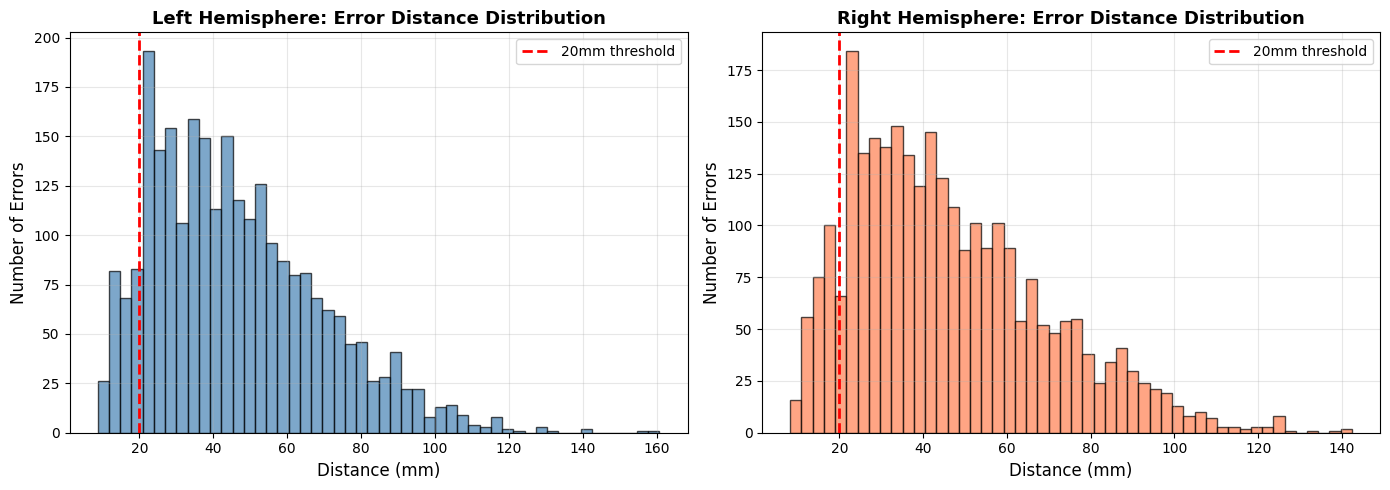

In [15]:
# =============================================================================
# DEEPER ANALYSIS: WHERE ARE THE ERRORS ACTUALLY OCCURRING?
# =============================================================================

print("\n" + "="*80)
print("DEEPER ERROR ANALYSIS")
print("="*80)

# 1. Distance distribution of ALL errors
def analyze_error_distances(cm, distance_matrix, hemisphere_name):
    """Analyze the spatial distribution of misclassifications."""
    
    # Get coordinates of all errors
    error_distances = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if cm[i, j] > 0:  # If there's an error
                error_distances.extend([distance_matrix[i, j]] * int(cm[i, j]))
    
    error_distances = np.array(error_distances)
    
    print(f"\n{hemisphere_name} Hemisphere - Error Distance Distribution:")
    print(f"  Total errors: {len(error_distances):,}")
    print(f"  Mean error distance: {error_distances.mean():.1f}mm")
    print(f"  Median error distance: {np.median(error_distances):.1f}mm")
    print(f"  Min: {error_distances.min():.1f}mm, Max: {error_distances.max():.1f}mm")
    
    # Distance bins
    bins = [0, 10, 20, 30, 50, 100, 200]
    print(f"\n  Errors by distance:")
    for i in range(len(bins)-1):
        count = ((error_distances >= bins[i]) & (error_distances < bins[i+1])).sum()
        pct = (count / len(error_distances)) * 100
        print(f"    {bins[i]:3d}-{bins[i+1]:3d}mm: {count:5,} ({pct:5.1f}%)")
    
    count = (error_distances >= bins[-1]).sum()
    pct = (count / len(error_distances)) * 100
    print(f"    >{bins[-1]:3d}mm: {count:5,} ({pct:5.1f}%)")
    
    return error_distances

left_error_dist = analyze_error_distances(cm_left, distance_matrix_lh, "Left")
right_error_dist = analyze_error_distances(cm_right, distance_matrix_rh, "Right")

# 2. Visualize error distance distribution
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(left_error_dist, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(20, color='red', linestyle='--', linewidth=2, label=f'{DISTANCE_THRESHOLD}mm threshold')
ax1.set_xlabel('Distance (mm)', fontsize=12)
ax1.set_ylabel('Number of Errors', fontsize=12)
ax1.set_title('Left Hemisphere: Error Distance Distribution', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(right_error_dist, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(20, color='red', linestyle='--', linewidth=2, label=f'{DISTANCE_THRESHOLD}mm threshold')
ax2.set_xlabel('Distance (mm)', fontsize=12)
ax2.set_ylabel('Number of Errors', fontsize=12)
ax2.set_title('Right Hemisphere: Error Distance Distribution', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")

In [16]:
# Errors with different thresholds
print("\n" + "="*80)
print("COMPARISON: ERROR CAPTURE AT DIFFERENT DISTANCE THRESHOLDS")
print("="*80)

thresholds = [10, 20, 30, 40, 50, 60, 80, 100]

for hemi, error_dist in [("Left", left_error_dist), ("Right", right_error_dist)]:
    print(f"\n{hemi} Hemisphere:")
    print(f"{'Threshold':<12} | {'Errors Captured':<18} | {'Percentage'}")
    print("-" * 55)
    
    for thresh in thresholds:
        count = (error_dist < thresh).sum()
        pct = (count / len(error_dist)) * 100
        print(f"  <{thresh:3d}mm     | {count:6,} / {len(error_dist):,}        | {pct:5.1f}%")

print("\n" + "="*80)
print("Most errors occur between 30-60mm - consider this your 'confusion zone'")
print("="*80)


COMPARISON: ERROR CAPTURE AT DIFFERENT DISTANCE THRESHOLDS

Left Hemisphere:
Threshold    | Errors Captured    | Percentage
-------------------------------------------------------
  < 10mm     |     13 / 2,611        |   0.5%
  < 20mm     |    254 / 2,611        |   9.7%
  < 30mm     |    749 / 2,611        |  28.7%
  < 40mm     |  1,181 / 2,611        |  45.2%
  < 50mm     |  1,602 / 2,611        |  61.4%
  < 60mm     |  1,944 / 2,611        |  74.5%
  < 80mm     |  2,378 / 2,611        |  91.1%
  <100mm     |  2,549 / 2,611        |  97.6%

Right Hemisphere:
Threshold    | Errors Captured    | Percentage
-------------------------------------------------------
  < 10mm     |      8 / 2,791        |   0.3%
  < 20mm     |    277 / 2,791        |   9.9%
  < 30mm     |    788 / 2,791        |  28.2%
  < 40mm     |  1,293 / 2,791        |  46.3%
  < 50mm     |  1,734 / 2,791        |  62.1%
  < 60mm     |  2,087 / 2,791        |  74.8%
  < 80mm     |  2,522 / 2,791        |  90.4%
  <100m